# Speed Bump Detector (YOLOv8) — trainv2
Object detector for **speed bumps** (and rumble strips), trained on the Roboflow
[`speed-bump-detection-se0eh`](https://universe.roboflow.com/speed-bump-detection/speed-bump-detection-se0eh)
dataset (2 classes: `Speed-Bump`, `Rumble Strip`).

This is separate from `trainv1` (the autoroute/urbaine/rurale road-type classifier) — that one stays untouched.
This notebook only produces one artifact: `speed_bump_detector.pt`, a YOLO weights file with the same
call pattern as the traffic-sign model already in `fullwithsigns` (`YOLO(weights_path)` → `.predict(image_path)`).

Pedestrian + crosswalk detection (from the `N_O_2` dataset) and weather / safety-distance are separate,



## 1. Setup & imports

In [1]:
!pip install ultralytics roboflow --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.5 MB/s eta 0:00:00


In [2]:
import os
import shutil
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO
import torch

print("Ultralytics/torch check:")
print("  CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("  GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics/torch check:
  CUDA available: True
  GPU: Tesla T4


## 2. Config

In [3]:
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")  

ROBOFLOW_WORKSPACE = "speed-bump-detection"
ROBOFLOW_PROJECT = "speed-bump-detection-se0eh"
ROBOFLOW_VERSION = 14  

DATASET_FORMAT = "yolov8"   
DATA_DIR = "/kaggle/working/speed_bump_dataset"

RUNS_DIR = "/kaggle/working/runs"
RUN_NAME = "speed_bump_yolo"

MODEL_SIZE = "yolov8n.pt"   
IMG_SIZE = 640
EPOCHS = 60
BATCH = 16
PATIENCE = 10            


## 3. Download the labeled dataset from Roboflow
If `ROBOFLOW_VERSION` above turns out wrong, this cell's error message will usually tell you the valid
range — adjust and re-run.

In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)

version = project.version(ROBOFLOW_VERSION)
dataset = version.download(DATASET_FORMAT, location=DATA_DIR)

print("Dataset downloaded to:", dataset.location)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/speed_bump_dataset in yolov8:: 100%|██████████| 3396/3396 [00:00<00:00, 7256.22it/s]

Dataset downloaded to: /kaggle/working/speed_bump_dataset


## 3a. Discover the real class names / folder layout
Quick sanity pass — confirm `data.yaml` matches what we expect (2 classes) before wasting a training run
on a mislabeled path.

In [5]:
data_yaml_path = os.path.join(dataset.location, "data.yaml")

with open(data_yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print("data.yaml contents:")
print(data_config)

CLASS_NAMES = data_config["names"]
NUM_CLASSES = data_config["nc"]
print(f"\n{NUM_CLASSES} classes: {CLASS_NAMES}")

for split in ["train", "valid", "test"]:
    split_dir = os.path.join(dataset.location, split, "images")
    if os.path.exists(split_dir):
        count = len([f for f in os.listdir(split_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        print(f"  {split}: {count} images")
    else:
        print(f"  {split}: not found at {split_dir}")


data.yaml contents:
{'names': ['Rumble Strip', 'Speed-Bump'], 'nc': 2, 'roboflow': {'license': 'CC BY 4.0', 'project': 'speed-bump-detection-se0eh', 'url': 'https://universe.roboflow.com/speed-bump-detection/speed-bump-detection-se0eh/dataset/14', 'version': 14, 'workspace': 'speed-bump-detection'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

2 classes: ['Rumble Strip', 'Speed-Bump']
  train: 1185 images
  valid: 253 images
  test: 254 images


## 4. Sanity-check a few labeled images before trusting anything
Draws the YOLO-format bounding boxes on top of a handful of training images — catch a broken label
format or wrong class mapping now, not after a 60-epoch run.

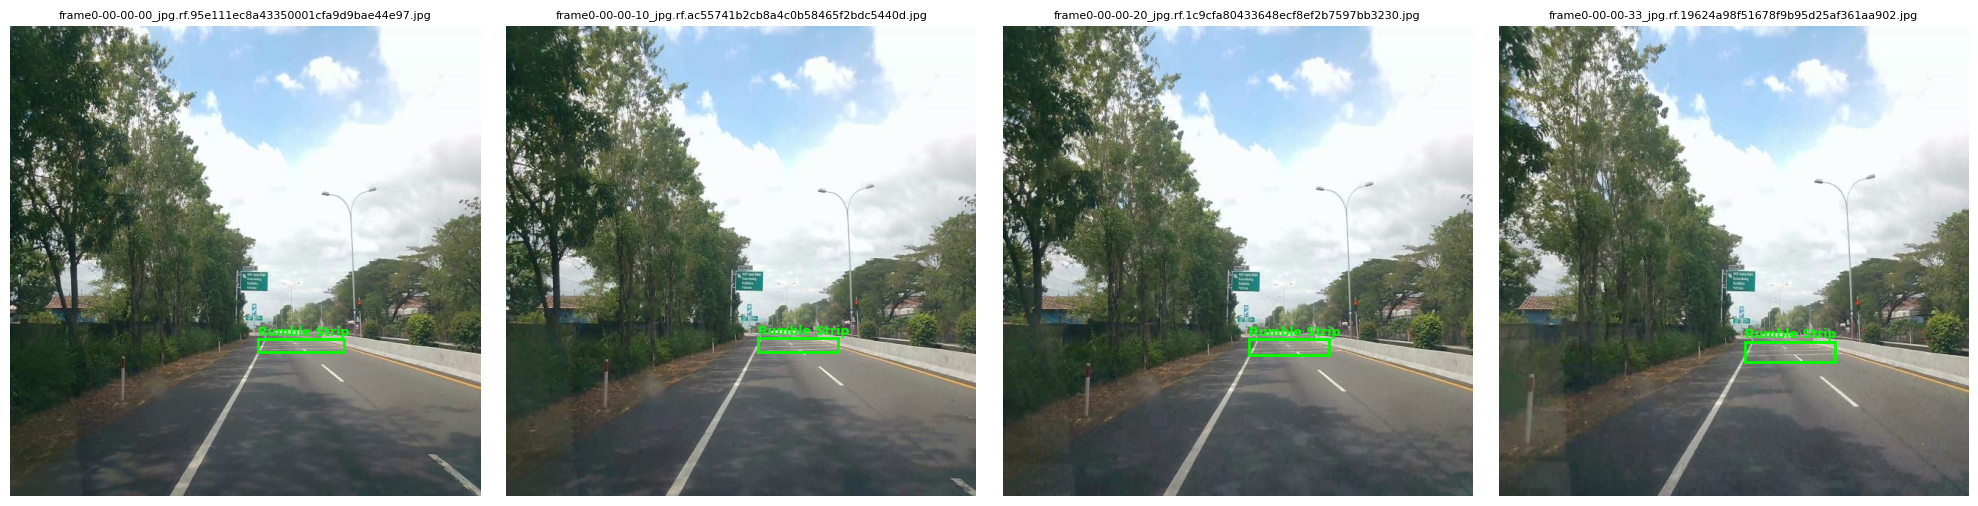

In [6]:
def preview_labeled_images(split="train", count=4):
    img_dir = os.path.join(dataset.location, split, "images")
    label_dir = os.path.join(dataset.location, split, "labels")

    img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])[:count]

    fig, axes = plt.subplots(1, len(img_files), figsize=(5 * len(img_files), 5))
    if len(img_files) == 1:
        axes = [axes]

    for ax, img_file in zip(axes, img_files):
        img_path = os.path.join(img_dir, img_file)
        label_path = os.path.join(label_dir, os.path.splitext(img_file)[0] + ".txt")

        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    cls_id, xc, yc, bw, bh = map(float, line.strip().split())
                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    box_w = bw * w
                    box_h = bh * h
                    rect = patches.Rectangle((x1, y1), box_w, box_h, linewidth=2, edgecolor="lime", facecolor="none")
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 5, CLASS_NAMES[int(cls_id)], color="lime", fontsize=9, weight="bold")

        ax.set_title(img_file, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

preview_labeled_images("train", count=4)


## 5. Train the detector (transfer learning on YOLOv8n, COCO-pretrained)
Starting from COCO weights rather than from scratch — 1.7k images is a small dataset, and the low-level
edge/shape features from COCO transfer fine to bump-shaped road markings.

In [7]:
model = YOLO(MODEL_SIZE)

results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    patience=PATIENCE,
    project=RUNS_DIR,
    name=RUN_NAME,
    seed=42,
)


Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/speed_bump_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=speed_bump_yolo, nbs=64, nms=False, opset=None, optimize=False, optimi

## 6. Plot training curves
Ultralytics saves these automatically — just display them.

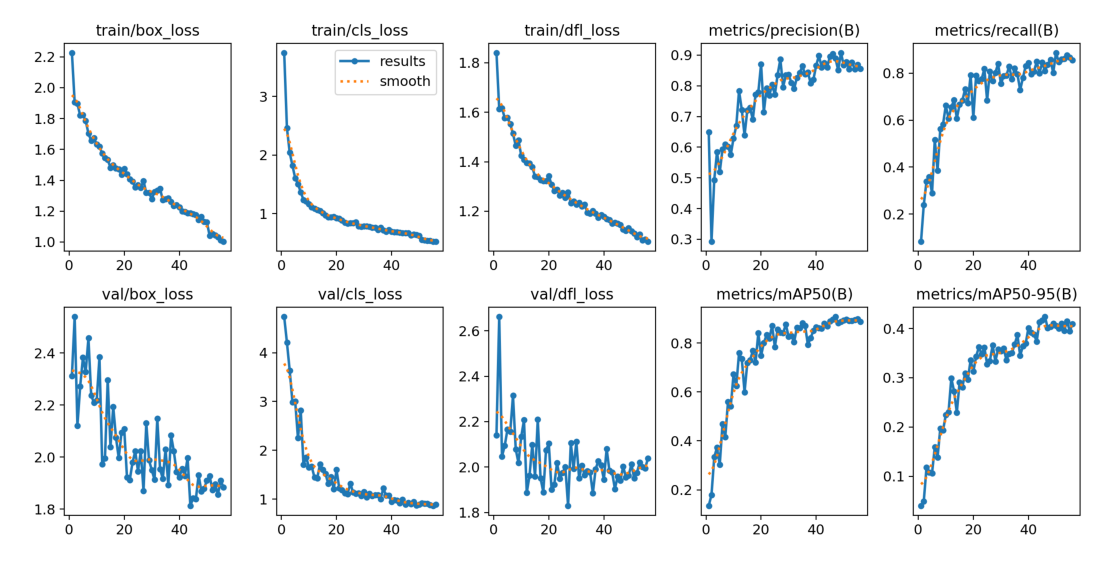

In [8]:
results_png = os.path.join(RUNS_DIR, RUN_NAME, "results.png")

if os.path.exists(results_png):
    img = Image.open(results_png)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print(f"results.png not found at {results_png} — check RUNS_DIR/RUN_NAME match what training printed above.")


## 7. Validate on the held-out validation split

In [9]:
metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("\nPer-class mAP50:")
for i, cls_name in CLASS_NAMES.items() if isinstance(CLASS_NAMES, dict) else enumerate(CLASS_NAMES):
    try:
        print(f"  {cls_name}: {metrics.box.ap50[i]:.3f}")
    except (IndexError, KeyError):
        pass


Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1840.6±379.0 MB/s, size: 60.2 KB)
val: Scanning /kaggle/working/speed_bump_dataset/valid/labels.cache... 253 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 253/253 117.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.3it/s 3.0s
                   all        253        255       0.91      0.814      0.903      0.422
          Rumble Strip        103        103      0.872      0.903      0.906      0.465
            Speed-Bump        150        152      0.948      0.725        0.9      0.379
Speed: 1.9ms preprocess, 4.1ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50: 0.9025708399732948
mAP50-95: 0.4220083837304938

Per-class mAP50:
  Ru

## 8. Quick visual test — run inference on a few validation images
Same eyeball check you did for the road-type sequences: does it actually look right before you trust the
numbers?

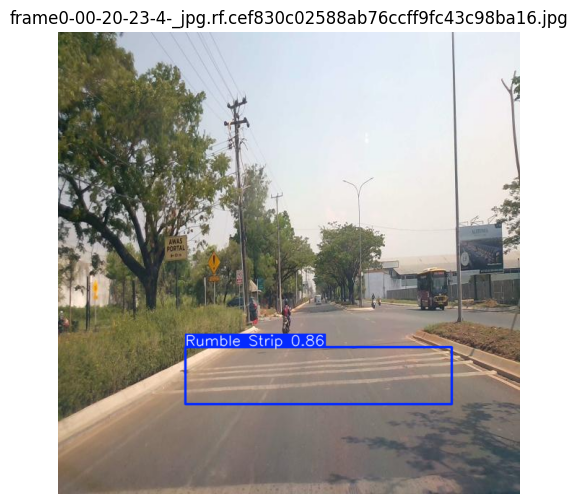

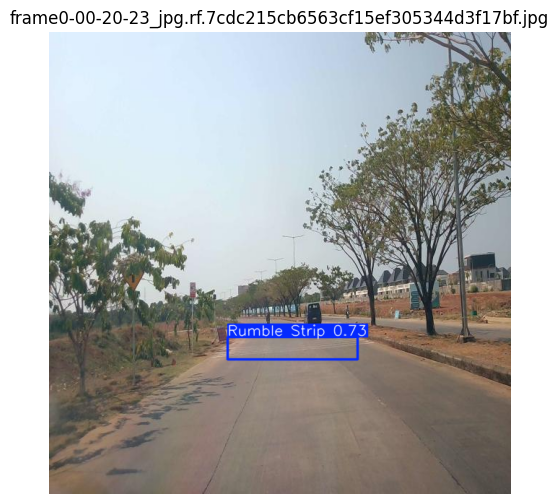

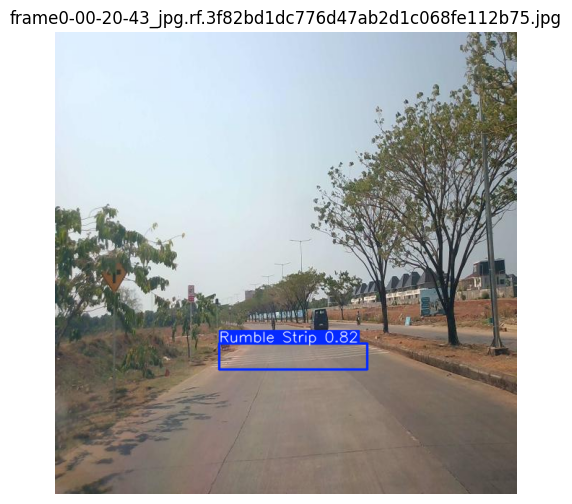

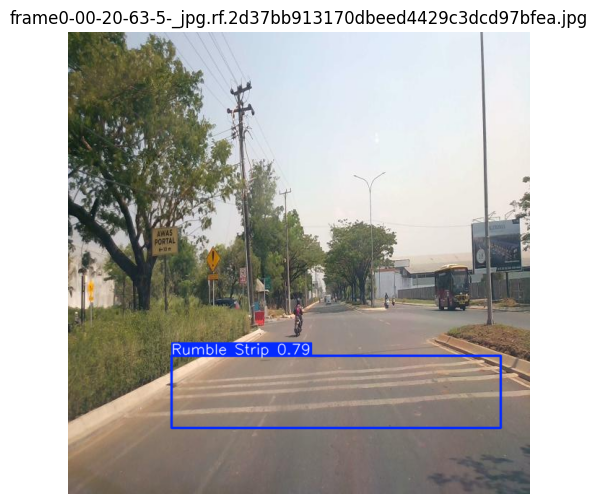

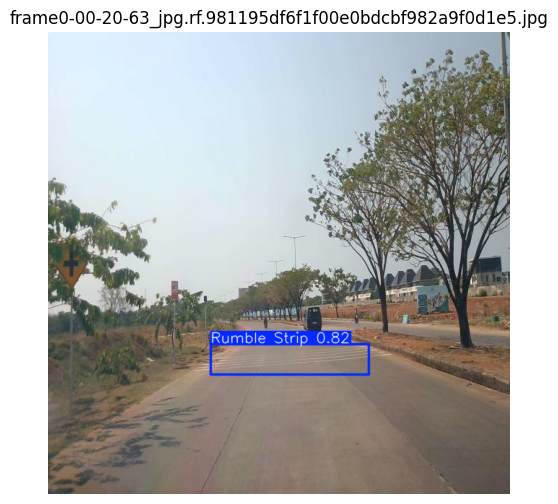

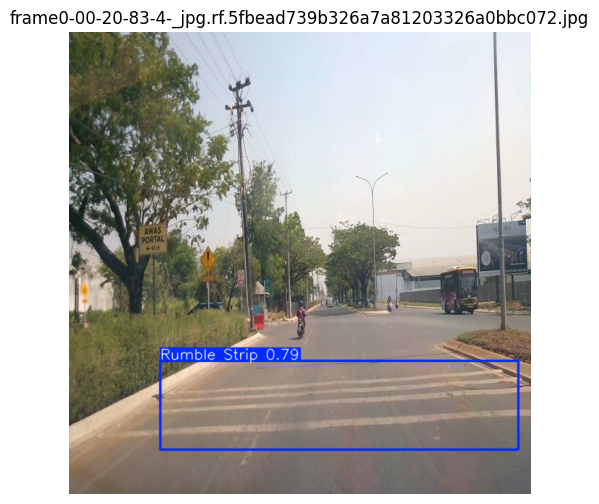

In [10]:
best_weights = os.path.join(RUNS_DIR, RUN_NAME, "weights", "best.pt")
trained_model = YOLO(best_weights)

val_img_dir = os.path.join(dataset.location, "valid", "images")
sample_files = sorted([f for f in os.listdir(val_img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])[:6]

for f in sample_files:
    img_path = os.path.join(val_img_dir, f)
    result = trained_model.predict(img_path, conf=0.4, verbose=False)[0]

    annotated = result.plot()  # numpy array, BGR->RGB handled by ultralytics internally for matplotlib? we convert below
    annotated_rgb = annotated[..., ::-1]

    plt.figure(figsize=(6, 6))
    plt.imshow(annotated_rgb)
    plt.title(f)
    plt.axis("off")
    plt.show()


## 9. Export weights
This is the only file `fullwithsigns` needs loaded the same way the traffic-sign model is loaded
(`YOLO(weights_path)` then `.predict(image_path)`), so wiring it into `detect_speed_bump()` later is a
copy-paste of the existing `detect_traffic_signs()` pattern.

In [11]:
export_path = "/kaggle/working/speed_bump_detector.pt"
shutil.copy(best_weights, export_path)

print(f"Saved to {export_path} — download from the notebook's Output tab.")
print(f"Classes: {CLASS_NAMES}")


Saved to /kaggle/working/speed_bump_detector.pt — download from the notebook's Output tab.
Classes: ['Rumble Strip', 'Speed-Bump']


## Next steps
1. Confirm this model looks right on your own test frames (not just the validation split) before trusting it.
2. Once you're happy: send the word and I'll do the same training notebook for pedestrian + crosswalk
   detection using `N_O_2` (filtered to just the `person` and `cross walk` classes out of its 70 — training
   on all 70 would be overkill and slower for no benefit to your use case).
3. After both detectors are trained, we wire `speed_bump_detector.pt` and the ped/crosswalk model into
   `fullwithsigns`: two new `detect_x()` functions + extending the override-priority chain we discussed
   (pedestrian-in-path > stop/red light > crosswalk > speed bump > ... > base road-type speed).
4. Weather and safety-distance come after that.
